Select a stock from the following list:
['AAPL', 'MSFT', 'GOOG', 'AMZN', 'FB']


Enter the symbol of the stock:  AAPL
Enter the number of years you want to do MCSimulation:  3
Enter the initial investment:  100


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Average Cumulative Returns - SPY,Average Cumulative Returns - AAPL
0,100.073005,100.110286
1,100.126453,100.184309
2,100.173528,100.258527
3,100.289745,100.386445
4,100.331316,100.592620
...,...,...
751,130.917870,227.833537
752,131.103470,228.164630
753,131.242198,228.403649
754,131.241053,228.973417


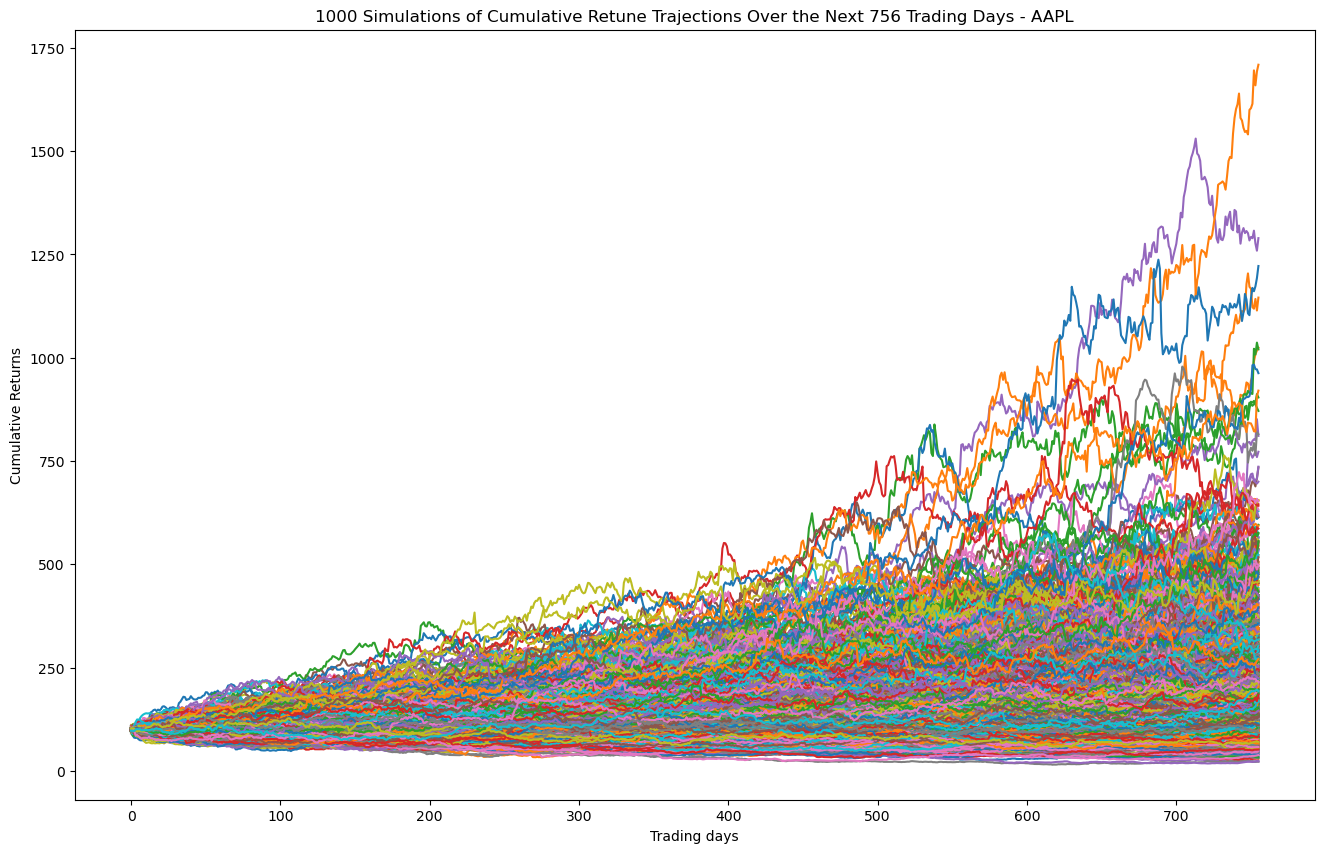

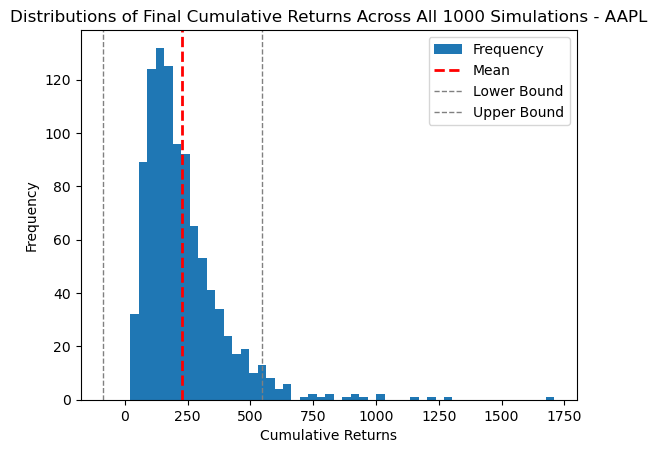

                    Value
count         1000.000000
mean           229.657189
std            160.968478
min             22.531436
25%            124.727462
50%            189.682711
75%            290.405414
max           1709.318750
95% CI Lower   -85.841027
95% CI Upper   545.155405
Select a stock from the following list:
['AAPL', 'MSFT', 'GOOG', 'AMZN', 'FB']


In [ ]:
import datetime as dt
import pandas as pd
from pandas_datareader import data as pdr
import yfinance as yf     
import numpy as np
import matplotlib.pyplot as plt

def Monte_Carlo_Simulation():
    
    # Let user choose the symbol of the ticker.
    stock_list = ["AAPL", "MSFT", "GOOG", "AMZN", "FB"]
    print("Select a stock from the following list:")
    print(stock_list)
    selected_stock = input("Enter the symbol of the stock: ")

    # Let user choose the number of years for MCSimulation, hence get the period for MCSimulation.
    num_years = int(input("Enter the number of years you want to do MCSimulation: "))

    # Let user input how much money he or she would like to invest
    initial_investment = float(input("Enter the initial investment: "))  

    # Get data from yahoo for both selected stock and S&P 500
    mc_end = dt.date.today()
    mc_start = mc_end - dt.timedelta(days=365*num_years)
    yf.pdr_override()
    stock_data_selected = pdr.get_data_yahoo(selected_stock, mc_start, mc_end)['Close']
    stock_data_spy = pdr.get_data_yahoo("SPY", mc_start, mc_end)['Close']

    # Prepare parameters for Monte Carlo Simulation
    trading_days = 252 * num_years  
    num_simulations = 1000  

    # Calculate cumulative returns and average cumulative returns for selected stock
    daily_returns_selected = stock_data_selected.pct_change().dropna().values 
    cumulative_returns_selected = np.zeros((trading_days, num_simulations))
    for i in range(num_simulations):
        daily_returns_random_selected = np.random.choice(daily_returns_selected, trading_days, replace=True)
        cumulative_returns_selected[:, i] = initial_investment * (1 + daily_returns_random_selected).cumprod(axis=0)    
  
    cumulative_returns_selected_df = pd.DataFrame(cumulative_returns_selected, columns=[f"Simulation {i}" for i in range(num_simulations)])
    average_cumulative_returns_selected_df = pd.DataFrame(
        cumulative_returns_selected_df.mean(axis=1), 
        columns=[f"Average Cumulative Returns - {selected_stock}"]
    )
 
    # Calculate cumulative returns and average cumulative returns for S&P 500
    daily_returns_spy = stock_data_spy.pct_change().dropna().values 
    cumulative_returns_spy = np.zeros((trading_days, num_simulations))
    for i in range(num_simulations):
        daily_returns_random_spy = np.random.choice(daily_returns_spy, trading_days, replace=True)
        cumulative_returns_spy[:, i] = initial_investment * (1 + daily_returns_random_spy).cumprod(axis=0)    
    # Create a DataFrame of the cumulative returns
    cumulative_returns_spy_df = pd.DataFrame(cumulative_returns_spy, columns=[f"Simulation {i}" for i in range(num_simulations)])
    # Create a DataFrame of the average cumulative returns
    average_cumulative_returns_spy_df = pd.DataFrame(
        cumulative_returns_spy_df.mean(axis=1), 
        columns=["Average Cumulative Returns - SPY"]
    )

    # Create a new DataFrame to compare the average cumulative returens of the selected stock and the S&P
    monte_carlo_return_table_df = pd.concat([average_cumulative_returns_spy_df, average_cumulative_returns_selected_df], axis=1)
    display(monte_carlo_return_table_df)

    # Plot Monte Carlo Simulation Results
    # 1000 Simulations of Cumulative Retune Trajections for the selected stock
    plt.figure(figsize=(16, 10))
    for i in range(num_simulations):
        plt.plot(cumulative_returns_selected_df.index, cumulative_returns_selected_df[f"Simulation {i}"])

    plt.xlabel("Trading days")
    plt.ylabel("Cumulative Returns")
    plt.title(f"1000 Simulations of Cumulative Retune Trajections Over the Next {trading_days} Trading Days - {selected_stock}")
    plt.show()

    # Plot Monte Carlo Simulation Results
    # The histogram for Distributions of Final Cumulative Returns Across All 1000 Simulations for the selected stock
    plt.hist(cumulative_returns_selected[-1, :], bins=50, density=False, label="Frequency")
    plt.xlabel("Cumulative Returns")
    plt.ylabel("Frequency")
    plt.title(f"Distributions of Final Cumulative Returns Across All 1000 Simulations - {selected_stock}")

    # Prepare parameters for mean and 95% confidence interval for the histogram
    mean = np.mean(cumulative_returns_selected[-1, :])
    std = np.std(cumulative_returns_selected[-1, :])
    lower_bound = mean - 1.96 * std
    upper_bound = mean + 1.96 * std

    # Plot the mean and confidence interval as vertical lines in histogram
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(lower_bound, color='gray', linestyle='dashed', linewidth=1, label='Lower Bound')
    plt.axvline(upper_bound, color='gray', linestyle='dashed', linewidth=1, label='Upper Bound')

    plt.legend()
    plt.show()

    # Generate summary statistics from the Monte Carlo simulation
    def summarize_cumulative_return(cumulative_returns_selected):
        summary = {}
        summary['count'] = cumulative_returns_selected.shape[1]
        summary['mean'] = mean
        summary['std'] = std
        summary['min'] = cumulative_returns_selected[-1].min()
        summary['25%'] = np.percentile(cumulative_returns_selected[-1, :], 25)
        summary['50%'] = np.percentile(cumulative_returns_selected[-1, :], 50)
        summary['75%'] = np.percentile(cumulative_returns_selected[-1, :], 75)
        summary['max'] = cumulative_returns_selected[-1].max()
        summary['95% CI Lower'] = lower_bound
        summary['95% CI Upper'] = upper_bound
        return pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

    print(summarize_cumulative_return(cumulative_returns_selected))
    
    return Monte_Carlo_Simulation()

Monte_Carlo_Simulation()